# Clase 6: Forecasting como problema de regresión lineal vs no lineal
## Demanda Energética - Paraguay (SIN)

**Ing. Diego Stalder, DSc**


FIUNA · 31 de Agosto de 2026

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga y Exploración de Datos

In [2]:
# Cargar datos
df = pd.read_csv('complete-dataset.csv', parse_dates=['DATETIME'], index_col='DATETIME')

# Ajustar timezone
df.index = pd.to_datetime(df.index, utc=True)
df.index = df.index.tz_localize(None)

print(f"Shape: {df.shape}")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"Frecuencia: {pd.infer_freq(df.index)}")
df.head()

Shape: (131481, 8)
Período: 2008-01-01 03:00:00 a 2023-01-01 02:00:00
Frecuencia: None


,SIN,T02M,RH2M,PRSS,TPP6,U10M,V10M,ISHOLIDAY
DATETIME,,,,,,,,
2008-01-01 03:00:00,1060.5,24.463579,96.798320,999.585909,0.000629,-1.613880,-1.142420,1.0
2008-01-01 04:00:00,990.0,24.314531,96.065988,999.059392,0.000419,-1.624135,-1.256589,1.0
2008-01-01 05:00:00,957.5,24.165483,95.333657,998.532875,0.000210,-1.634390,-1.370759,1.0
2008-01-01 06:00:00,919.5,24.016435,94.601325,998.006359,0.000000,-1.644645,-1.484929,1.0
2008-01-01 07:00:00,890.8,23.667572,94.257455,998.982867,0.000000,-1.273453,-1.629541,1.0


In [3]:
# Estadísticas descriptivas
df['SIN'].describe()

count    131481.000000
mean       1603.116585
std         531.222433
min         622.400000
25%        1207.000000
50%        1517.000000
75%        1914.000000
max        4212.000000
Name: SIN, dtype: float64

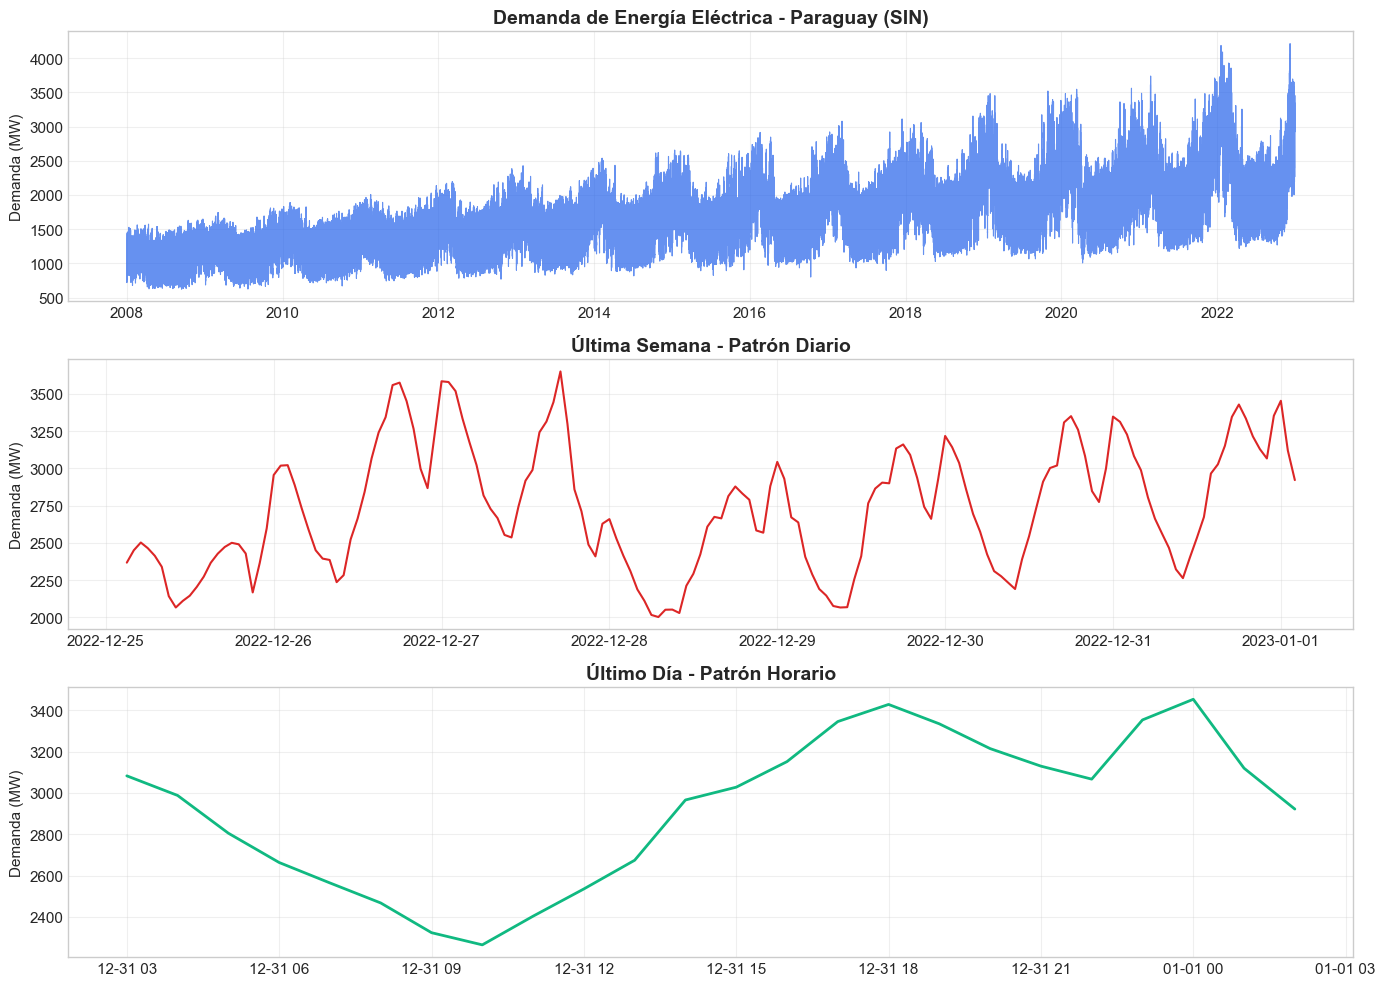

In [4]:
# Visualización de la serie
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Serie completa
axes[0].plot(df.index, df['SIN'], color='#2563EB', alpha=0.7, linewidth=0.8)
axes[0].set_title('Demanda de Energía Eléctrica - Paraguay (SIN)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Demanda (MW)')
axes[0].grid(True, alpha=0.3)

# Última semana
ultima_semana = df.iloc[-168:]
axes[1].plot(ultima_semana.index, ultima_semana['SIN'], color='#DC2626', linewidth=1.5)
axes[1].set_title('Última Semana - Patrón Diario', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Demanda (MW)')
axes[1].grid(True, alpha=0.3)

# Último día
ultimo_dia = df.iloc[-24:]
axes[2].plot(ultimo_dia.index, ultimo_dia['SIN'], color='#10B981', linewidth=2)
axes[2].set_title('Último Día - Patrón Horario', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Demanda (MW)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Resample Diario

In [5]:
# Resample diario
df_daily = df.resample('D').agg({
    'SIN': ['mean', 'max', 'min', 'std'],
    'T02M': 'mean',
    'RH2M': 'mean',
    'PRSS': 'mean',
    'TPP6': 'sum',
    'U10M': 'mean',
    'V10M': 'mean',
    'ISHOLIDAY': 'max'
})

# Aplanar columnas
df_daily.columns = ['_'.join(col).strip() for col in df_daily.columns.values]
df_daily = df_daily.rename(columns={
    'SIN_mean': 'SIN_avg',
    'SIN_max': 'SIN_max',
    'SIN_min': 'SIN_min',
    'SIN_std': 'SIN_std',
    'T02M_mean': 'T02M',
    'RH2M_mean': 'RH2M',
    'PRSS_mean': 'PRSS',
    'TPP6_sum': 'TPP6',
    'U10M_mean': 'U10M',
    'V10M_mean': 'V10M',
    'ISHOLIDAY_max': 'ISHOLIDAY'
})

print(f"Shape diario: {df_daily.shape}")
df_daily.head()

Shape diario: (5480, 11)


,SIN_avg,SIN_max,SIN_min,SIN_std,T02M,RH2M,PRSS,TPP6,U10M,V10M,ISHOLIDAY
DATETIME,,,,,,,,,,,
2008-01-01,825.323810,1083.0,719.3,113.866052,26.903721,82.723834,999.590099,0.017829,-1.307691,-1.700825,1.0
2008-01-02,1100.200000,1296.3,903.3,120.063020,27.479930,82.452904,998.034219,0.017571,-1.259228,-0.950300,1.0
2008-01-03,1197.700000,1440.6,1021.5,116.836478,28.103424,84.811673,999.754422,0.031497,-0.479752,-1.637689,0.0
2008-01-04,1160.625000,1458.0,1010.5,113.950559,27.575141,88.905702,1002.503172,0.070734,-0.690503,0.661984,0.0
2008-01-05,1085.079167,1405.0,936.5,107.756101,27.742631,77.062529,1001.759937,0.005508,-0.967034,1.915215,0.0


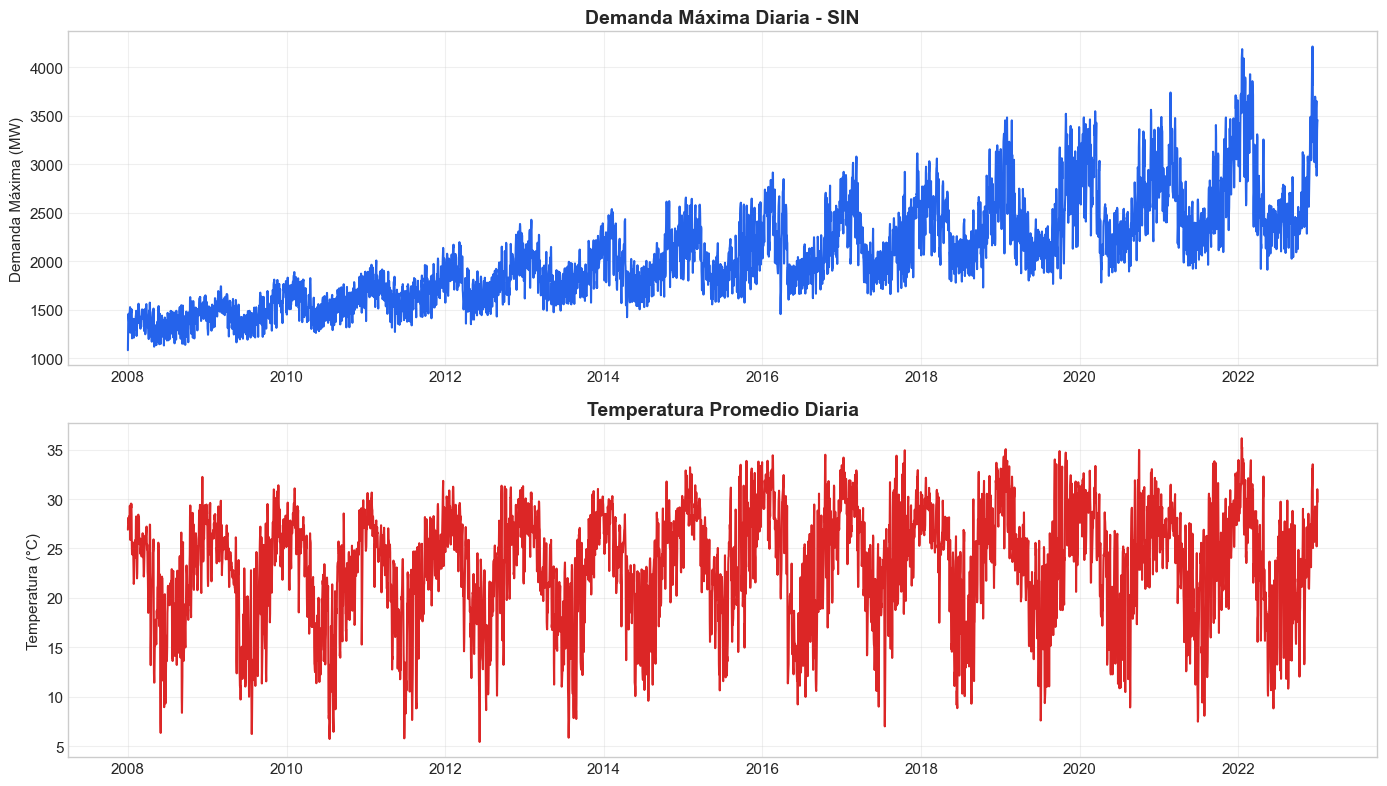

In [6]:
# Visualización de la serie diaria
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_daily.index, df_daily['SIN_max'], color='#2563EB', linewidth=1.5)
axes[0].set_title('Demanda Máxima Diaria - SIN', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Demanda Máxima (MW)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_daily.index, df_daily['T02M'], color='#DC2626', linewidth=1.5)
axes[1].set_title('Temperatura Promedio Diaria', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Temperatura (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Descomposición STL

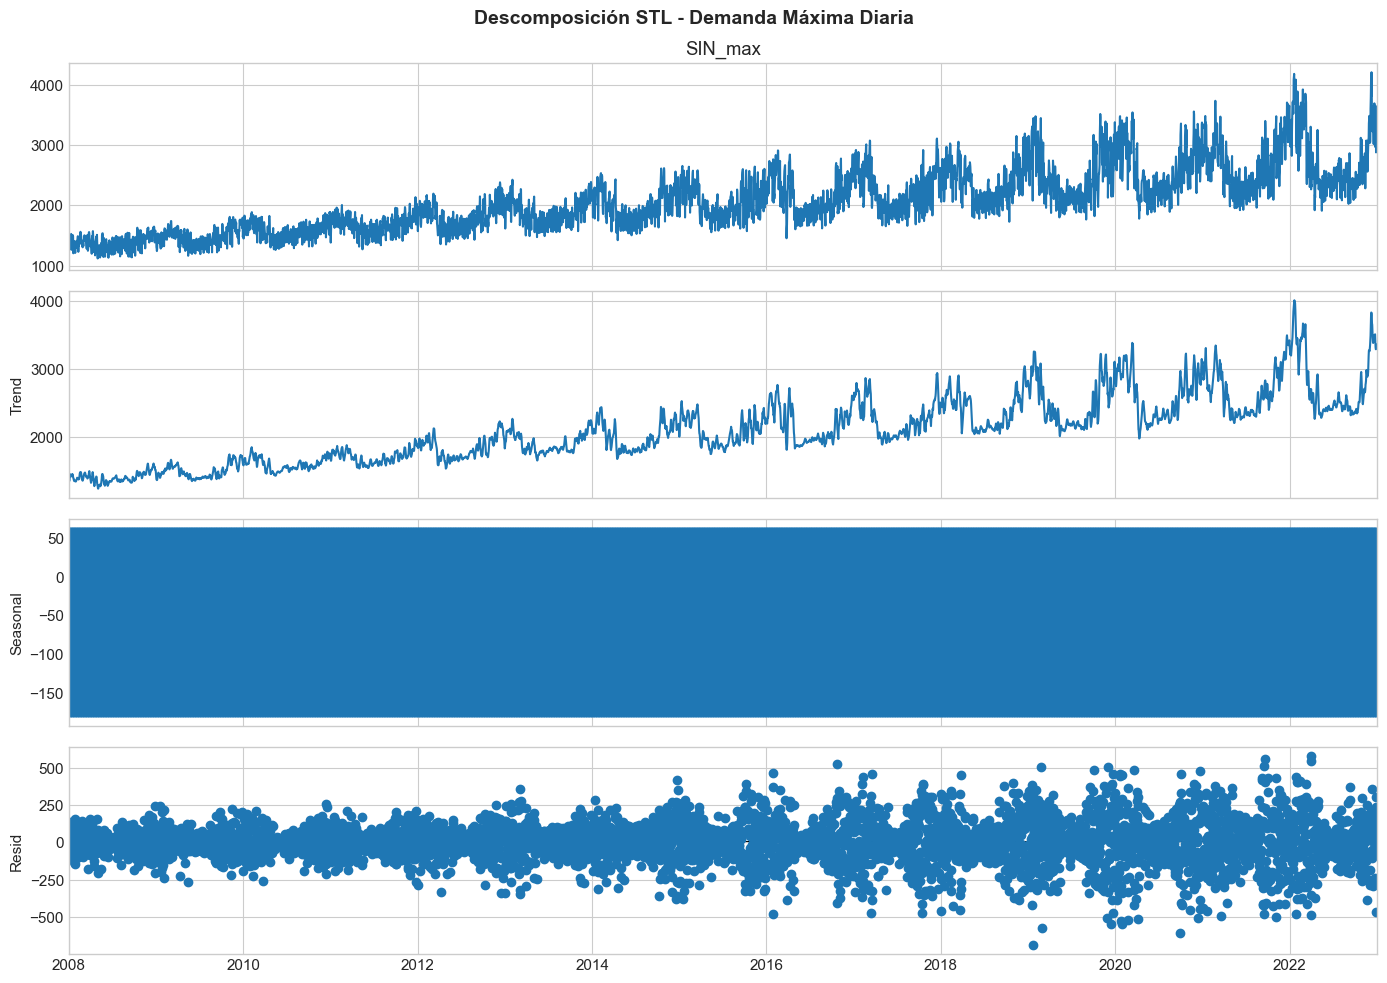

In [7]:
# Descomposición de la serie diaria
descomp = seasonal_decompose(
    df_daily['SIN_max'],
    model='additive',
    period=7  # Estacionalidad semanal
)

# Visualización
fig = descomp.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Descomposición STL - Demanda Máxima Diaria', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Extraer componentes
tendencia = descomp.trend
estacionalidad = descomp.seasonal
residuo = descomp.resid

print("="*50)
print("Componentes de la Serie")
print("="*50)
print(f"Std Tendencia:      {tendencia.std():.2f} kWh")
print(f"Std Estacionalidad: {estacionalidad.std():.2f} kWh")
print(f"Std Residuo:        {residuo.std():.2f} kWh")

Componentes de la Serie
Std Tendencia:      491.68 kWh
Std Estacionalidad: 82.40 kWh
Std Residuo:        129.68 kWh


## 5. Análisis de Estacionariedad

In [9]:
def test_estacionariedad(serie, nombre="Serie"):
    """Aplica tests ADF y KPSS a una serie"""
    print(f"\n{'='*50}")
    print(f"Tests de Estacionariedad - {nombre}")
    print(f"{'='*50}")
    
    # ADF Test
    adf_result = adfuller(serie.dropna(), autolag='AIC')
    print(f"\nADF Test:")
    print(f"  Estadístico: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Críticos: {adf_result[4]}")
    
    if adf_result[1] < 0.05:
        print("  → Rechaza H0: Serie es estacionaria")
    else:
        print("  → No rechaza H0: Serie NO es estacionaria")
    
    # KPSS Test
    kpss_result = kpss(serie.dropna(), regression='c')
    print(f"\nKPSS Test:")
    print(f"  Estadístico: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    
    if kpss_result[1] < 0.05:
        print("  → Rechaza H0: Serie NO es estacionaria")
    else:
        print("  → No rechaza H0: Serie es estacionaria")
    
    return adf_result, kpss_result

In [10]:
# Test sobre serie original
test_estacionariedad(df_daily['SIN_max'], "SIN_max Original")


Tests de Estacionariedad - SIN_max Original

ADF Test:
  Estadístico: -1.8961
  p-value: 0.3339
  Críticos: {'1%': np.float64(-3.4315513193059908), '5%': np.float64(-2.8620708627986335), '10%': np.float64(-2.5670525772661414)}
  → No rechaza H0: Serie NO es estacionaria

KPSS Test:
  Estadístico: 10.0721
  p-value: 0.0100
  → Rechaza H0: Serie NO es estacionaria


C:\Users\yoda\AppData\Local\Temp\ipykernel_21540\3608649973.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie.dropna(), regression='c')


((np.float64(-1.8960798383705915),
  np.float64(0.3339075199108823),
  33,
  5446,
  {'1%': np.float64(-3.4315513193059908),
   '5%': np.float64(-2.8620708627986335),
   '10%': np.float64(-2.5670525772661414)},
  np.float64(70248.23996768249)),
 (np.float64(10.07211978973118),
  np.float64(0.01),
  43,
  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}))

In [11]:
# Test sobre diferencia estacional (7 días)
serie_diff7 = df_daily['SIN_max'].diff(7).dropna()
test_estacionariedad(serie_diff7, "SIN_max - diff(7)")


Tests de Estacionariedad - SIN_max - diff(7)

ADF Test:
  Estadístico: -15.9147
  p-value: 0.0000
  Críticos: {'1%': np.float64(-3.4315528661360912), '5%': np.float64(-2.862071546204342), '10%': np.float64(-2.5670529410654956)}
  → Rechaza H0: Serie es estacionaria

KPSS Test:
  Estadístico: 0.0073
  p-value: 0.1000
  → No rechaza H0: Serie es estacionaria


C:\Users\yoda\AppData\Local\Temp\ipykernel_21540\3608649973.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie.dropna(), regression='c')


((np.float64(-15.9146842962187),
  np.float64(8.049616880574955e-29),
  33,
  5439,
  {'1%': np.float64(-3.4315528661360912),
   '5%': np.float64(-2.862071546204342),
   '10%': np.float64(-2.5670529410654956)},
  np.float64(70271.75940042302)),
 (np.float64(0.007279632608979878),
  np.float64(0.1),
  6,
  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}))

## 6. Análisis de Correlación - ACF y PACF

**ACF (Autocorrelation Function)**: Mide la correlación entre la serie y sus rezagos.

**PACF (Partial Autocorrelation Function)**: Mide la correlación eliminando la influencia de rezagos intermedios.

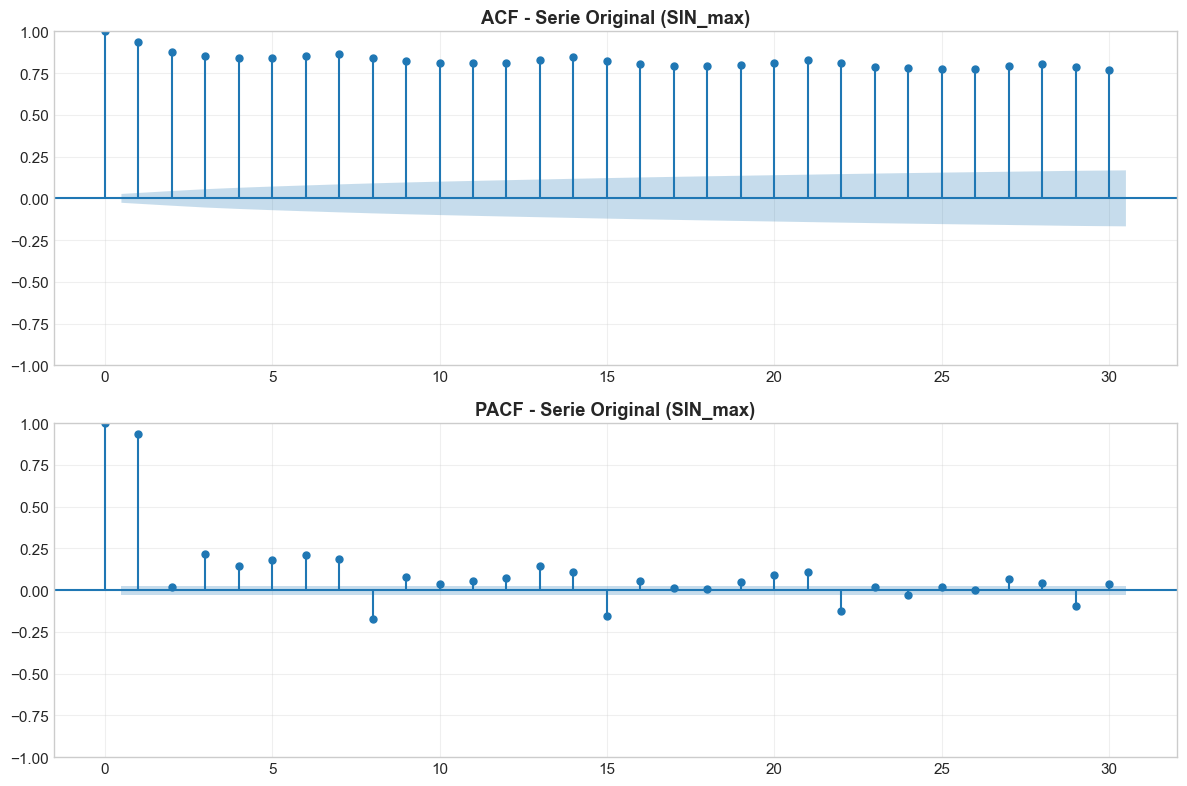

In [12]:
# ACF y PACF de la serie original
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df_daily['SIN_max'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF - Serie Original (SIN_max)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(df_daily['SIN_max'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF - Serie Original (SIN_max)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

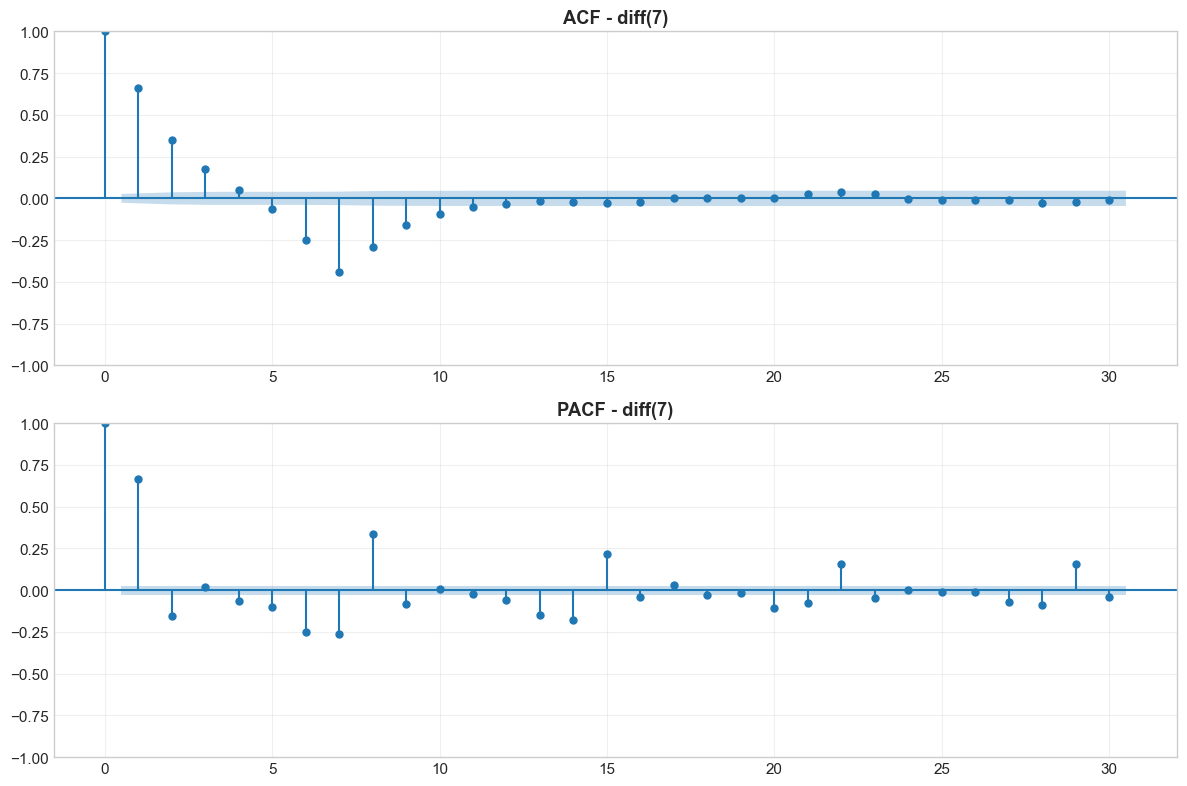

In [13]:
# ACF y PACF de la serie diferenciada (diff 7)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(serie_diff7, lags=30, ax=axes[0])
axes[0].set_title('ACF - diff(7)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(serie_diff7, lags=30, ax=axes[1])
axes[1].set_title('PACF - diff(7)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Ingeniería de Features

### Estrategia: Modelar la Diferencia Estacional

Como la serie **NO** es estacionaria en niveles pero **SÍ** lo es con diff(7), vamos a:

1. **Predecir la diferencia estacional**: $\Delta_7 y_t = y_t - y_{t-7}$
2. **Entrenar el modelo** con la variable objetivo = diff7
3. **Reconstruir el pronóstico**: $\hat{y}_t = \hat{\Delta_7 y_t} + y_{t-7}$

Esto asegura que el modelo aprenda sobre una serie estacionaria.

In [ ]:
# Crear la variable objetivo como diferencia estacional (diff 7)
df_feat = df_daily.copy()
df_feat['SIN_max_diff7'] = df_feat['SIN_max'].diff(7)

# Crear features de lags sobre la serie original (para usar como predictores)
def create_lag_features(df, col, lags=[1, 2, 3, 7, 14, 21, 28]):
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

def create_rolling_features(df, col, windows=[3, 7, 14]):
    for w in windows:
        df[f'{col}_rolling_{w}_mean'] = df[col].rolling(w).mean()
        df[f'{col}_rolling_{w}_std'] = df[col].rolling(w).std()
    return df

def create_date_features(df):
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    return df

# Aplicar features
df_feat = create_lag_features(df_feat, 'SIN_max', lags=[1, 2, 3, 7, 14, 21, 28])
df_feat = create_rolling_features(df_feat, 'SIN_max', windows=[3, 7, 14])
df_feat = create_lag_features(df_feat, 'T02M', lags=[1, 2, 3, 7])
df_feat = create_date_features(df_feat)

# Eliminar filas con NaN
df_feat = df_feat.dropna()

print(f"Shape después de features: {df_feat.shape}")
df_feat.head()

Shape después de features: (5452, 33)


,SIN_avg,SIN_max,SIN_min,SIN_std,T02M,RH2M,PRSS,TPP6,U10M,V10M,...,SIN_max_rolling_14_mean,SIN_max_rolling_14_std,T02M_lag_1,T02M_lag_2,T02M_lag_3,T02M_lag_7,dayofweek,month,dayofyear,is_weekend
DATETIME,,,,,,,,,,,,,,,,,,,,,
2008-01-29,937.262500,1309.3,747.3,131.365762,21.699070,90.430396,999.113049,-0.000454,-0.723572,2.369731,...,1373.685714,101.393019,21.418670,23.089682,23.943694,25.004418,1,1,29,0
2008-01-30,1021.779167,1360.4,820.5,139.551695,24.886958,80.338186,997.403603,0.000433,1.129465,2.552114,...,1363.214286,93.855772,21.699070,21.418670,23.089682,25.424458,2,1,30,0
2008-01-31,1066.420833,1385.8,877.5,134.537633,25.168726,73.430427,996.264451,-0.000227,1.501032,1.998677,...,1356.985714,88.764969,24.886958,21.699070,21.418670,25.351243,3,1,31,0
2008-02-01,1101.895833,1371.5,930.5,122.249486,25.477198,75.536503,996.042804,0.003503,1.607137,1.691039,...,1347.592857,78.488210,25.168726,24.886958,21.699070,25.600078,4,2,32,0
2008-02-02,1046.875000,1402.0,937.7,118.943217,25.473661,72.893064,997.959149,0.000000,1.671480,1.982864,...,1341.742857,70.157282,25.477198,25.168726,24.886958,23.943694,5,2,33,1


In [16]:
# Verificar estacionariedad de la variable objetivo diff7
test_estacionariedad(df_feat['SIN_max_diff7'], "SIN_max_diff7 (con features)")


Tests de Estacionariedad - SIN_max_diff7 (con features)

ADF Test:
  Estadístico: -15.8799
  p-value: 0.0000
  Críticos: {'1%': np.float64(-3.431557530619635), '5%': np.float64(-2.862073607019783), '10%': np.float64(-2.567054038105758)}
  → Rechaza H0: Serie es estacionaria

KPSS Test:
  Estadístico: 0.0073
  p-value: 0.1000
  → No rechaza H0: Serie es estacionaria


C:\Users\yoda\AppData\Local\Temp\ipykernel_21540\3608649973.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie.dropna(), regression='c')


((np.float64(-15.879867525060627),
  np.float64(8.783352351421216e-29),
  33,
  5418,
  {'1%': np.float64(-3.431557530619635),
   '5%': np.float64(-2.862073607019783),
   '10%': np.float64(-2.567054038105758)},
  np.float64(70016.90296205593)),
 (np.float64(0.007311668863770171),
  np.float64(0.1),
  6,
  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}))

## 8. Split Temporal

In [17]:
# Split temporal (80% train, 20% test)
split_idx = int(0.8 * len(df_feat))
train = df_feat.iloc[:split_idx].copy()
test = df_feat.iloc[split_idx:].copy()

print(f"Train: {train.index.min()} a {train.index.max()}")
print(f"Test:  {test.index.min()} a {test.index.max()}")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train: 2008-01-29 00:00:00 a 2020-01-06 00:00:00
Test:  2020-01-07 00:00:00 a 2023-01-01 00:00:00
Train shape: (4361, 33)
Test shape:  (1091, 33)


## 9. Modelo Baseline - Regresión Lineal (sobre diff7)

In [28]:
# Definir features
feature_cols = [
    'SIN_max_lag_1', 'SIN_max_lag_2', 'SIN_max_lag_3',
    'SIN_max_lag_7', 'SIN_max_lag_14', 'SIN_max_lag_21', 'SIN_max_lag_28',
    #'SIN_max_rolling_3_mean', 'SIN_max_rolling_3_std',
    #'SIN_max_rolling_7_mean', 'SIN_max_rolling_7_std',
    #'SIN_max_rolling_14_mean', 'SIN_max_rolling_14_std',
    'T02M_lag_1', 'T02M_lag_2', 'T02M_lag_3', 'T02M_lag_7',
    'dayofweek', 'month', 'is_weekend'
]

# Variable objetivo: diff7
target_col = 'SIN_max_diff7'

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test_diff = test[target_col]  # Diferencia a predecir

# Guardar los valores reales de SIN_max para reconstrucción
y_test_real = test['SIN_max']
y_train_real = train['SIN_max']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nVariable objetivo: {target_col}")
print(f"Rango de diff7: [{y_train.min():.2f}, {y_train.max():.2f}] MW")

X_train shape: (4361, 14)
X_test shape:  (1091, 14)

Variable objetivo: SIN_max_diff7
Rango de diff7: [-1197.00, 1202.00] MW


In [29]:
X_train.head()

,SIN_max_lag_1,SIN_max_lag_2,SIN_max_lag_3,SIN_max_lag_7,SIN_max_lag_14,SIN_max_lag_21,SIN_max_lag_28,T02M_lag_1,T02M_lag_2,T02M_lag_3,T02M_lag_7,dayofweek,month,is_weekend
DATETIME,,,,,,,,,,,,,,
2008-01-29,1212.0,1313.5,1406.2,1384.6,1491.0,1456.0,1083.0,21.418670,23.089682,23.943694,25.004418,1,1,0
2008-01-30,1309.3,1212.0,1313.5,1394.5,1507.0,1467.0,1296.3,21.699070,21.418670,23.089682,25.424458,2,1,0
2008-01-31,1360.4,1309.3,1212.0,1393.6,1473.0,1490.0,1440.6,24.886958,21.699070,21.418670,25.351243,3,1,0
2008-02-01,1385.8,1360.4,1309.3,1385.0,1503.0,1526.7,1458.0,25.168726,24.886958,21.699070,25.600078,4,2,0
2008-02-02,1371.5,1385.8,1360.4,1406.2,1483.9,1263.6,1405.0,25.477198,25.168726,24.886958,23.943694,5,2,1


In [30]:
y_train.head()

DATETIME
2008-01-29   -75.3
2008-01-30   -34.1
2008-01-31    -7.8
2008-02-01   -13.5
2008-02-02    -4.2
Freq: D, Name: SIN_max_diff7, dtype: float64

In [31]:
# Entrenar modelo con escalado
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

# Predicciones en diff
y_pred_diff_train = pipeline_lr.predict(X_train)
y_pred_diff_test = pipeline_lr.predict(X_test)

# RECONSTRUIR: convertir diff a nivel
# y_pred = y_pred_diff + y_{t-7}
y_pred_train = y_pred_diff_train + train['SIN_max'].shift(7).values
y_pred_test = y_pred_diff_test + test['SIN_max'].shift(7).values

# NOTA: Los primeros valores pueden tener NaN, los ignoramos
# Usamos solo índices válidos
train_idx_valid = ~np.isnan(y_pred_train)
test_idx_valid = ~np.isnan(y_pred_test)

y_pred_train = y_pred_train[train_idx_valid]
y_train_valid = train['SIN_max'].values[train_idx_valid]

y_pred_test = y_pred_test[test_idx_valid]
y_test_valid = test['SIN_max'].values[test_idx_valid]

In [32]:
def calcular_metricas(y_true, y_pred, nombre=""):
    """Calcula métricas de evaluación"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*40}")
    print(f"Métricas - {nombre}")
    print(f"{'='*40}")
    print(f"MAE:  {mae:.2f} MW")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

In [33]:
# Evaluar en niveles (reconstruidos)
metricas_lr_train = calcular_metricas(y_train_valid, y_pred_train, "Regresión Lineal (diff7) - Train")
metricas_lr_test = calcular_metricas(y_test_valid, y_pred_test, "Regresión Lineal (diff7) - Test")


Métricas - Regresión Lineal (diff7) - Train
MAE:  91.18 MW
RMSE: 128.08 MW
R²:   0.9051
MAPE: 4.63%

Métricas - Regresión Lineal (diff7) - Test
MAE:  144.17 MW
RMSE: 195.09 MW
R²:   0.8157
MAPE: 5.37%


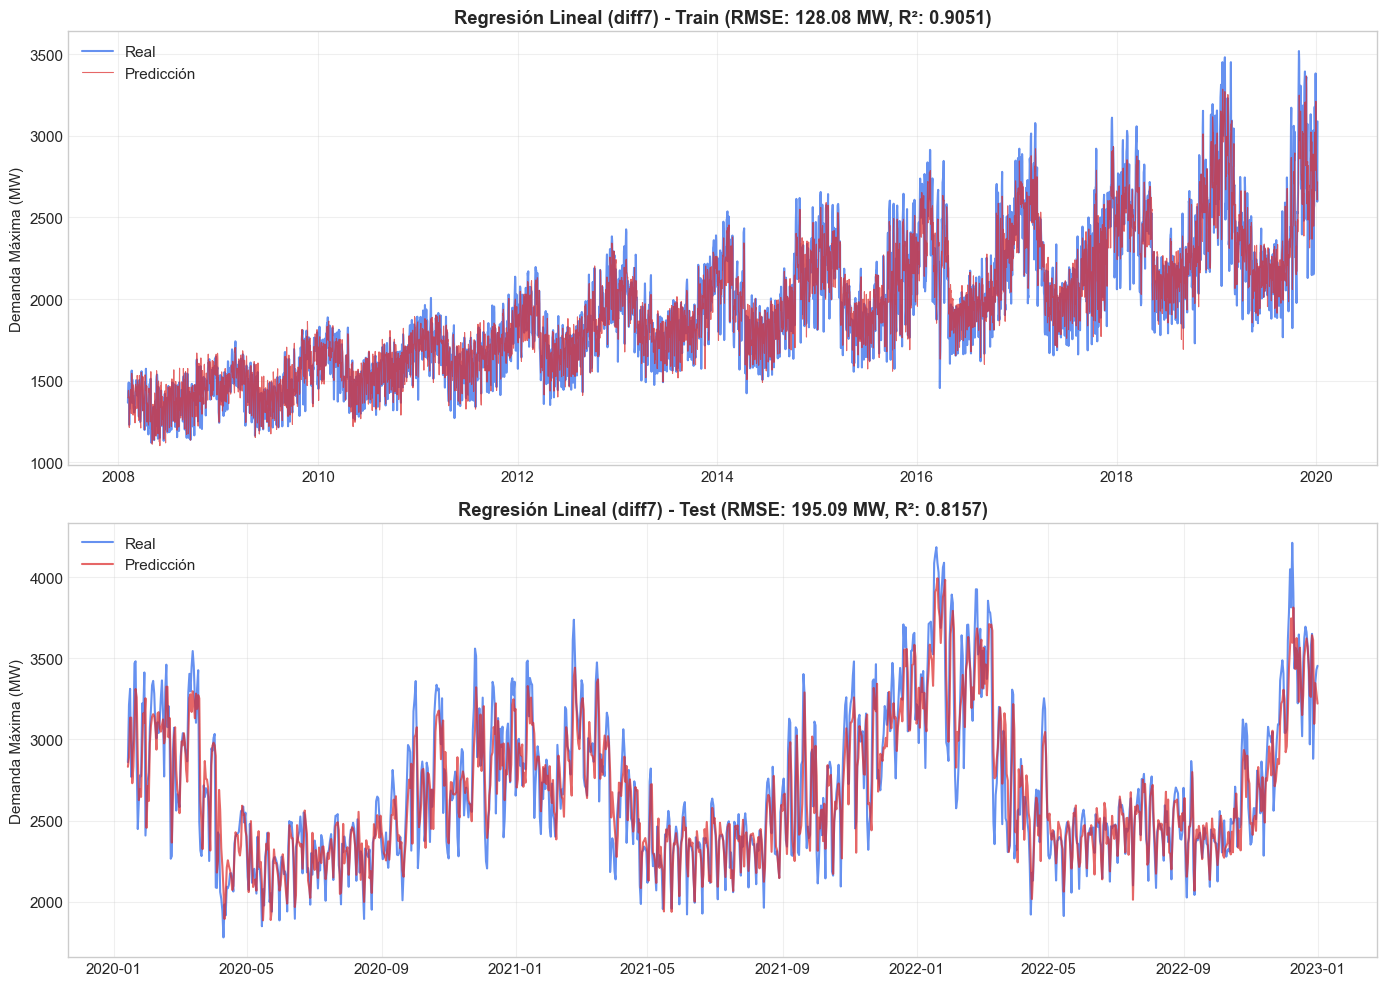

In [34]:
# Visualización de predicciones
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Train
train_dates = train.index[train_idx_valid]
axes[0].plot(train_dates, y_train_valid, label='Real', color='#2563EB', alpha=0.7)
axes[0].plot(train_dates, y_pred_train, label='Predicción', color='#DC2626', alpha=0.7, linewidth=0.8)
axes[0].set_title(f'Regresión Lineal (diff7) - Train (RMSE: {metricas_lr_train["rmse"]:.2f} MW, R²: {metricas_lr_train["r2"]:.4f})', 
                  fontweight='bold')
axes[0].set_ylabel('Demanda Máxima (MW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
test_dates = test.index[test_idx_valid]
axes[1].plot(test_dates, y_test_valid, label='Real', color='#2563EB', alpha=0.7)
axes[1].plot(test_dates, y_pred_test, label='Predicción', color='#DC2626', alpha=0.7)
axes[1].set_title(f'Regresión Lineal (diff7) - Test (RMSE: {metricas_lr_test["rmse"]:.2f} MW, R²: {metricas_lr_test["r2"]:.4f})',
                  fontweight='bold')
axes[1].set_ylabel('Demanda Máxima (MW)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Coeficientes
coeficientes = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': pipeline_lr.named_steps['regressor'].coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("Top 10 Features - Importancia en Regresión Lineal (diff7)")
print("="*50)
print(coeficientes.head(10).to_string(index=False))

Top 10 Features - Importancia en Regresión Lineal (diff7)
       Feature  Coeficiente
 SIN_max_lag_7  -380.840452
 SIN_max_lag_1   264.310735
    T02M_lag_2   -98.749701
    T02M_lag_1    85.018639
     dayofweek   -60.457441
 SIN_max_lag_3    41.766529
SIN_max_lag_21    29.564151
SIN_max_lag_14    27.951314
    T02M_lag_3    26.162708
SIN_max_lag_28    15.400226


## 10. Modelo Polinomial (sobre diff7)

In [37]:
def crear_modelo_polinomial(grado=2):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('regressor', LinearRegression())
    ])

In [40]:
# Probar diferentes grados
grados = [1, 2, 3,4]
resultados_poly = []

for grado in grados:
    modelo = crear_modelo_polinomial(grado)
    modelo.fit(X_train, y_train)
    
    # Predicciones en diff
    y_pred_diff_train = modelo.predict(X_train)
    y_pred_diff_test = modelo.predict(X_test)
    
    # Reconstruir a niveles
    y_pred_train = y_pred_diff_train + train['SIN_max'].shift(7).values
    y_pred_test = y_pred_diff_test + test['SIN_max'].shift(7).values
    
    # Filtrar NaN
    train_valid = ~np.isnan(y_pred_train)
    test_valid = ~np.isnan(y_pred_test)
    
    rmse_train = np.sqrt(mean_squared_error(
        train['SIN_max'].values[train_valid], 
        y_pred_train[train_valid]
    ))
    rmse_test = np.sqrt(mean_squared_error(
        test['SIN_max'].values[test_valid], 
        y_pred_test[test_valid]
    ))
    
    resultados_poly.append({
        'grado': grado,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

df_resultados_poly = pd.DataFrame(resultados_poly)
print(df_resultados_poly.to_string(index=False))

 grado  rmse_train   rmse_test
     1  128.076735  195.087026
     2  116.603297  186.053820
     3  101.143000  261.302973
     4   49.650413 1786.298604


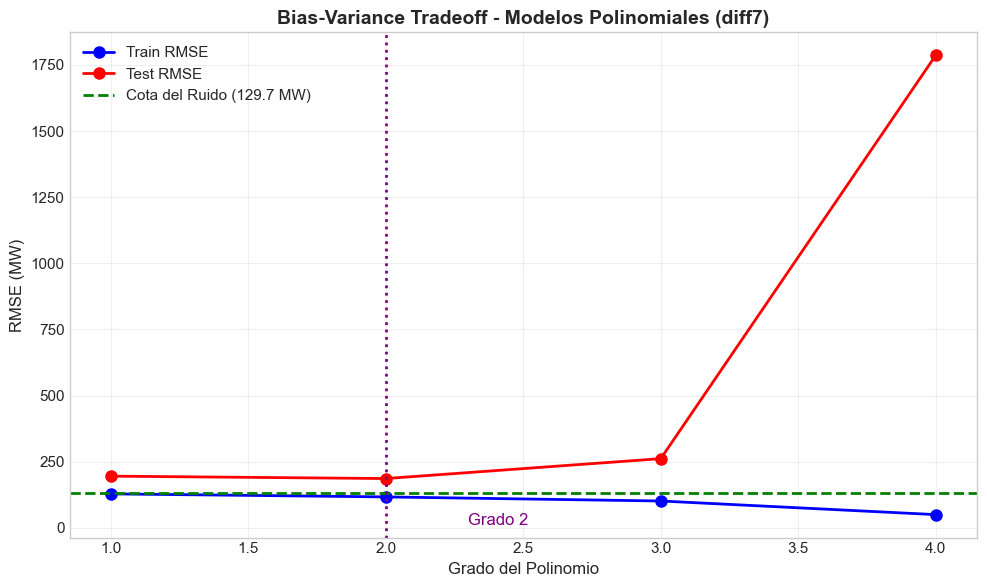

In [41]:
# Visualización del Bias-Variance Tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_resultados_poly['grado'], df_resultados_poly['rmse_train'], 
        'bo-', label='Train RMSE', linewidth=2, markersize=8)
ax.plot(df_resultados_poly['grado'], df_resultados_poly['rmse_test'], 
        'ro-', label='Test RMSE', linewidth=2, markersize=8)

# Cota del ruido (std del residuo de STL)
cota_ruido = residuo.std()
ax.axhline(y=cota_ruido, color='green', linestyle='--', linewidth=2, 
           label=f'Cota del Ruido ({cota_ruido:.1f} MW)')

ax.set_xlabel('Grado del Polinomio', fontsize=12)
ax.set_ylabel('RMSE (MW)', fontsize=12)
ax.set_title('Bias-Variance Tradeoff - Modelos Polinomiales (diff7)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Marcar punto óptimo
optimo = df_resultados_poly.loc[df_resultados_poly['rmse_test'].idxmin()]
ax.axvline(x=optimo['grado'], color='purple', linestyle=':', linewidth=2)
ax.text(optimo['grado'] + 0.3, 10, f'Grado {int(optimo["grado"])}', color='purple', fontsize=12)

plt.tight_layout()
plt.show()

## 11. Validación Cruzada Temporal (sobre diff7)

In [42]:
# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

print("Folds de TimeSeriesSplit:")
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {i+1}: Train {len(train_idx)} muestras, Val {len(val_idx)} muestras")

Folds de TimeSeriesSplit:
Fold 1: Train 731 muestras, Val 726 muestras
Fold 2: Train 1457 muestras, Val 726 muestras
Fold 3: Train 2183 muestras, Val 726 muestras
Fold 4: Train 2909 muestras, Val 726 muestras
Fold 5: Train 3635 muestras, Val 726 muestras


In [43]:
# GridSearchCV con TimeSeriesSplit
pipeline_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),
    ('regressor', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4]
}

grid = GridSearchCV(
    pipeline_poly,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

# Entrenar con diff7
grid.fit(X_train, y_train)

print("="*50)
print("Resultados de GridSearchCV (diff7)")
print("="*50)
print(f"Mejor grado: {grid.best_params_['poly__degree']}")
print(f"Mejor RMSE CV (en diff): {np.sqrt(-grid.best_score_):.4f} MW")

Resultados de GridSearchCV (diff7)
Mejor grado: 2
Mejor RMSE CV (en diff): 136.3017 MW


In [44]:
# Evaluar mejor modelo en test (reconstruido)
best_model = grid.best_estimator_

# Predicciones en diff
y_pred_diff_best_test = best_model.predict(X_test)

# Reconstruir a niveles
y_pred_best_test = y_pred_diff_best_test + test['SIN_max'].shift(7).values

# Filtrar NaN
test_valid = ~np.isnan(y_pred_best_test)
y_pred_best_test = y_pred_best_test[test_valid]
y_test_best_valid = test['SIN_max'].values[test_valid]

rmse_best = np.sqrt(mean_squared_error(y_test_best_valid, y_pred_best_test))
r2_best = r2_score(y_test_best_valid, y_pred_best_test)

print(f"\nEvaluación en Test Set (niveles reconstruidos):")
print(f"RMSE: {rmse_best:.2f} MW")
print(f"R²:   {r2_best:.4f}")


Evaluación en Test Set (niveles reconstruidos):
RMSE: 186.05 MW
R²:   0.8324


## 12. Análisis de Residuos (en niveles)

In [45]:
# Residuos del mejor modelo (en escala original)
residuos = y_test_best_valid - y_pred_best_test

print("="*50)
print("Estadísticos de Residuos (niveles)")
print("="*50)
print(f"Media: {residuos.mean():.4f} MW")
print(f"Std:   {residuos.std():.4f} MW")
print(f"Min:   {residuos.min():.4f} MW")
print(f"Max:   {residuos.max():.4f} MW")

Estadísticos de Residuos (niveles)
Media: 31.5942 MW
Std:   183.3517 MW
Min:   -936.0469 MW
Max:   599.6999 MW


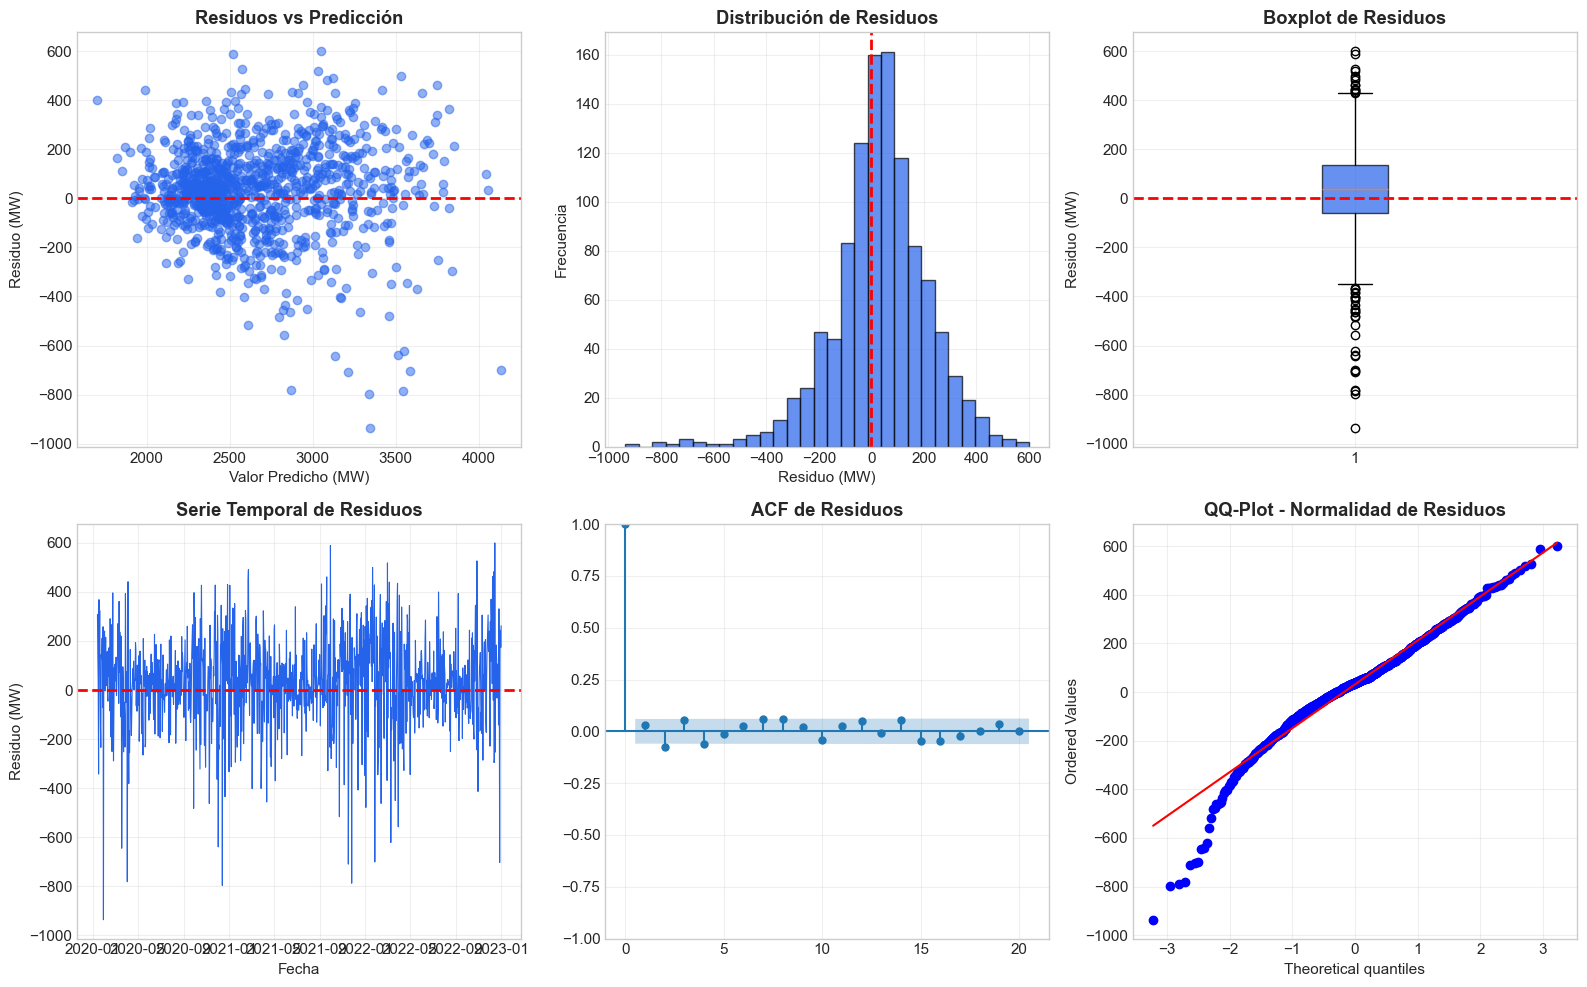

In [46]:
# Gráficos de diagnóstico de residuos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Residuos vs Predicción
axes[0,0].scatter(y_pred_best_test, residuos, alpha=0.5, color='#2563EB')
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Valor Predicho (MW)')
axes[0,0].set_ylabel('Residuo (MW)')
axes[0,0].set_title('Residuos vs Predicción', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# 2. Histograma de residuos
axes[0,1].hist(residuos, bins=30, color='#2563EB', edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residuo (MW)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_title('Distribución de Residuos', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# 3. Boxplot de residuos
axes[0,2].boxplot(residuos, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#2563EB', alpha=0.7))
axes[0,2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,2].set_ylabel('Residuo (MW)')
axes[0,2].set_title('Boxplot de Residuos', fontweight='bold')
axes[0,2].grid(True, alpha=0.3)

# 4. Serie temporal de residuos
test_dates_valid = test.index[test_valid]
axes[1,0].plot(test_dates_valid, residuos, color='#2563EB', linewidth=0.8)
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Fecha')
axes[1,0].set_ylabel('Residuo (MW)')
axes[1,0].set_title('Serie Temporal de Residuos', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 5. ACF de residuos
plot_acf(residuos, lags=20, ax=axes[1,1])
axes[1,1].set_title('ACF de Residuos', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# 6. QQ-plot
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[1,2])
axes[1,2].set_title('QQ-Plot - Normalidad de Residuos', fontweight='bold')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Test Ljung-Box para autocorrelación de residuos
lb_test_resid = acorr_ljungbox(residuos, lags=10, return_df=True)
print("Test Ljung-Box - Residuos (niveles):")
print(lb_test_resid)

if lb_test_resid['lb_pvalue'].iloc[-1] > 0.05:
    print("\n✅ Los residuos NO tienen autocorrelación significativa (ruido blanco)")
else:
    print("\n⚠️ Los residuos tienen autocorrelación significativa (el modelo es mejorable)")

Test Ljung-Box - Residuos (niveles):
      lb_stat  lb_pvalue
1    0.958203   0.327640
2    7.030697   0.029737
3   10.113269   0.017627
4   13.984169   0.007346
5   14.107674   0.014940
6   14.817501   0.021725
7   18.689249   0.009219
8   22.765567   0.003679
9   23.157306   0.005853
10  24.943512   0.005454

⚠️ Los residuos tienen autocorrelación significativa (el modelo es mejorable)


## 13. Comparación Final de Modelos (versión diff7)

In [48]:
# Comparación final
print("="*60)
print("Comparación de Modelos (diff7 vs niveles)")
print("="*60)
print(f"\n{'Modelo':<30} {'RMSE Train':<12} {'RMSE Test':<12} {'R² Test':<10}")
print("-"*60)

# RMSE Train para polinomial
best_model = grid.best_estimator_
y_pred_diff_best_train = best_model.predict(X_train)
y_pred_best_train = y_pred_diff_best_train + train['SIN_max'].shift(7).values
train_valid = ~np.isnan(y_pred_best_train)
rmse_train_poly = np.sqrt(mean_squared_error(
    train['SIN_max'].values[train_valid], 
    y_pred_best_train[train_valid]
))

print(f"{'Regresión Lineal (diff7)':<30} {metricas_lr_train['rmse']:<12.2f} {metricas_lr_test['rmse']:<12.2f} {metricas_lr_test['r2']:<10.4f}")
print(f"{'Polinomial (GridSearch, diff7)':<30} {rmse_train_poly:<12.2f} {rmse_best:<12.2f} {r2_best:<10.4f}")

Comparación de Modelos (diff7 vs niveles)

Modelo                         RMSE Train   RMSE Test    R² Test   
------------------------------------------------------------
Regresión Lineal (diff7)       128.08       195.09       0.8157    
Polinomial (GridSearch, diff7) 116.60       186.05       0.8324    
